# Removing non-building objects (e.g. vehicles) in DSM 

In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
from rasterio.windows import Window
import rasterio
import numpy as np
import cv2
import zipfile
import os
import sys
import shutil

## clip building from DSM by vector

First, get DSM-DEM with QGIS and then start this step
clip building from the (DSM-DEM) raster './data/DSM/DSM-DTM_50cm.tif'
!!!the extant of the raster is changed in this step!!!
QGIS>>right click layer>>export>>save as>>change the extent manually>>>>in python>>set nan as 0
Make sure to use the correct layer from the geopackage file if there are multiple layers
layer_name = 'Buildings'  # replace this with the actual layer name in your geopackage file

In [9]:

layer_name = 'Buildings'  # replace this with the actual layer name in your geopackage file
gdf = gpd.read_file('./data/DSM/UrbISBuildings_04000.gpkg', layer=layer_name)

# Extract the geometries in GeoJSON format
geometries = [geometry.__geo_interface__ for geometry in gdf.geometry]

# Load the raster file
with rasterio.open('./data/DSM/DSM-DTM_50cm.tif') as src:
    # Clip the raster with the geometries
    meta = src.meta
    out_image, out_transform = mask(src, geometries, crop=True)
    
    # Copy the metadata
    out_meta = src.meta.copy()


# Update the metadata to reflect the new dimensions and transform
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})
# Save the clipped raster to a new file
output_raster = './data/DSM/DSM-DTM_50cm_building.tif'
with rasterio.open(output_raster, 'w', **out_meta) as dest:
    dest.write(out_image)

print(f"Raster clipping completed and saved to '{output_raster}'")

Raster clipping completed and saved to './data/DSM/DSM-DTM_50cm_building.tif'


### get rid of the negative values in the raster

In [61]:

input_raster = './data/DSM/DSM-DTM_50cm_outer_building.tif'
output_raster = './data/DSM/DSM-DTM_50cm_outer_building.tif'

# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
    # Get the metadata
    meta = src.meta

# Find values less than 0 and change them to 0
raster_data[raster_data < 0] = 0

# Write the modified raster to a new file
with rasterio.open(output_raster, 'w', **meta) as dest:
    dest.write(raster_data, 1)

print(f"Raster values modified and saved to '{output_raster}'")

Raster values modified and saved to './data/DSM/DSM-DTM_50cm_outer_building.tif'


## get vegetation (with vehicles!) profile by given hights
DSM-DTM_50cm_vegetation_ground.tif is produced by QGIS Raster>>raster calculator, './data/DSM/DSM-DTM_50cm.tif' - './data/DSM/DSM-DTM_50cm_building.tif'
!!!be aware of the extant of the output raster of "raster calculator"!!!

In [14]:

# File paths
input_raster = './data/DSM/DSM-DTM_50cm_vegetation04+.tif'
output_raster_below = './data/DSM/DSM-DTM_50cm_vegetation04-20.tif'
output_raster_above = './data/DSM/DSM-DTM_50cm_vegetation2.0.tif'
'''
input_raster = './data/DSM/DSM-DTM_50cm_vegetation.tif'
output_raster_below = './data/DSM/DSM-DTM_50cm_vegetation02-04.tif'
output_raster_above = './data/DSM/DSM-DTM_50cm_vegetation04+.tif'


input_raster = './data/DSM/DSM-DTM_50cm_vegetation_ground.tif'
output_raster_below = './data/DSM/DSM-DTM_50cm_ground.tif'
output_raster_above = './data/DSM/DSM-DTM_50cm_vegetation.tif'
'''
# Threshold value
threshold = 2


# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
    # Get the metadata
    meta = src.meta
src.close
# Create binary masks based on the threshold
below_threshold = np.where(raster_data <= threshold, raster_data, np.nan)
above_threshold = np.where(raster_data > threshold, raster_data, np.nan)

# Update metadata to reflect single band
meta.update(count=1, dtype=rasterio.float32)

# Write the below threshold raster
with rasterio.open(output_raster_below, 'w', **meta) as dest:
    dest.write(below_threshold.astype(rasterio.float32), 1)
dest.close
# Write the above threshold raster
with rasterio.open(output_raster_above, 'w', **meta) as dest:
    dest.write(above_threshold.astype(rasterio.float32), 1)
dest.close
print(f"Rasters divided and saved to '{output_raster_below}' and '{output_raster_above}'")

Rasters divided and saved to './data/DSM/DSM-DTM_50cm_vegetation04-20.tif' and './data/DSM/DSM-DTM_50cm_vegetation2.0.tif'


In [13]:
src.close
dest.close

<bound method DatasetBase.close of <closed DatasetWriter name='./data/DSM/DSM-DTM_50cm_vegetation2.0.tif' mode='w'>>

In [11]:
# get rid of the negative values in the raster
input_raster = './data/DSM/DSM-DTM_50cm_outer0-2.tif'
output_raster = './data/DSM/DSM-DTM_50cm_outer0-2.tif'

# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
    # Get the metadata
    meta = src.meta
src.close
# Find values less than 0 and change them to 0
raster_data[raster_data < 0] = 0
raster_data = np.nan_to_num(raster_data, nan=0)

# Write the modified raster to a new file
with rasterio.open(output_raster, 'w', **meta) as dest:
    dest.write(raster_data, 1)
dest.close
print(f"Raster values modified and saved to '{output_raster}'")

Raster values modified and saved to './data/DSM/DSM-DTM_50cm_outer0-2.tif'


In [69]:
# get rid of the negative values in the raster
input_raster = './data/DSM/DSM-DTM_50cm_outer_vegetation.tif'
output_raster = './data/DSM/DSM-DTM_50cm_outer_vegetation.tif'

# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
    # Get the metadata
    meta = src.meta
src.close
# Find values less than 0 and change them to 0
raster_data[raster_data < 0] = 0
raster_data = np.nan_to_num(raster_data, nan=0)

# Write the modified raster to a new file
with rasterio.open(output_raster, 'w', **meta) as dest:
    dest.write(raster_data, 1)
dest.close
print(f"Raster values modified and saved to '{output_raster}'")

Raster values modified and saved to './data/DSM/DSM-DTM_50cm_outer_vegetation.tif'


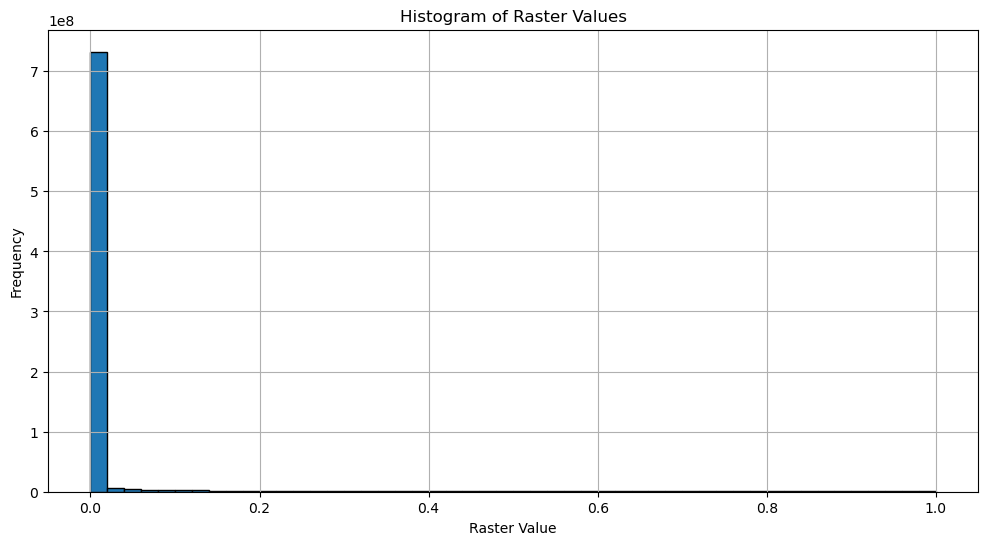

In [25]:


# File path
input_raster = './data/DSM/DSM-DTM_50cm_ground.tif'

# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
src.close
# Flatten the array to a 1D array and filter out nan values
raster_flat = raster_data.flatten()
raster_flat = raster_flat[~np.isnan(raster_flat)]

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.hist(raster_flat, bins=50, edgecolor='black')
plt.title('Histogram of Ground Raster Values')
plt.xlabel('Raster Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [4]:
# get rid of the negative values in the raster
#DSM-DTM_50cm_ground_building.tif is produced by QGIS Raster>>raster calculator
#!!!be aware of the extant of the output raster of "raster calculator"!!!
input_raster = './data/DSM/DSM-DTM_50cm_ground_building.tif'
output_raster = './data/DSM/DSM-DTM_50cm_ground_building.tif'

# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
    # Get the metadata
    meta = src.meta

# Find values less than 0 and change them to 0
raster_data[raster_data < 0] = 0
raster_data = np.nan_to_num(raster_data, nan=0)

# Write the modified raster to a new file
with rasterio.open(output_raster, 'w', **meta) as dest:
    dest.write(raster_data, 1)

print(f"Raster values modified and saved to '{output_raster}'")

Raster values modified and saved to './data/DSM/DSM-DTM_50cm_ground_building.tif'


## split the DSM into pieces
The memory of local computer cannot handle citywide circularity calculation.

In [4]:
#Before this step, add DEM back to the building raster with QGIS but keep the vegetation as (DEM-DTM)
#DSM_50cm_ground_building.tif is produced by QGIS Raster>>raster calculator
#!!!be aware of the extant of the output raster of "raster calculator"!!!
#split DSM
import os
import rasterio
from rasterio.windows import Window

# Function to save raster part
def save_raster_part(src, window, output_path):
    kwargs = src.meta.copy()
    kwargs.update({
        'height': window.height,
        'width': window.width,
        'transform': rasterio.windows.transform(window, src.transform)
    })
        
    with rasterio.open(output_path, 'w', **kwargs) as dest:
        dest.write(src.read(window=window))

# Define the input raster file path
sub = 'ground'#'vegetation_without_cars'#'ground_building'# 
input_raster = './data/DSM/DSM_50cm_ground.tif' # './data/DSM/DSM_50cm_' + sub + '.tif'# #'./data/DSM/DSM-DTM_50cm_' + sub + '.tif'

# Define the number of columns and rows to split the image into
num_cols = 10  # For example, split into 3 columns
num_rows = 10  # and 2 rows

# Open the input raster using rasterio
with rasterio.open(input_raster) as src:
    # Define width and height of the raster
    width = src.width
    height = src.height

    # Calculate the dimensions of each piece (cell)
    cell_width = width // num_cols
    cell_height = height // num_rows

    # Create output directory if it doesn't exist
    output_dir = './data/DSM/'+sub+'_split'
    os.makedirs(output_dir, exist_ok=True)

    # Generate windows and save each part
    for row in range(num_rows):
        for col in range(num_cols):
            window = Window(
                col * cell_width,
                row * cell_height,
                cell_width if (col != num_cols - 1) else (width - col * cell_width),
                cell_height if (row != num_rows - 1) else (height - row * cell_height)
            )
            output_path = os.path.join(output_dir, 'DSM_'+sub+f'_part_{row}_{col}.tif')
            save_raster_part(src, window, output_path)
    
print("Raster successfully divided and saved in:", output_dir)

Raster successfully divided and saved in: ./data/DSM/ground_split


In [4]:

#split DSM 0.4-2.0
import os
import rasterio
from rasterio.windows import Window

# Function to save raster part
def save_raster_part(src, window, output_path):
    kwargs = src.meta.copy()
    kwargs.update({
        'height': window.height,
        'width': window.width,
        'transform': rasterio.windows.transform(window, src.transform)
    })
        
    with rasterio.open(output_path, 'w', **kwargs) as dest:
        dest.write(src.read(window=window))

# Define the input raster file path
#sub = 'ground_building'# 'vegetation'
input_raster = './data/DSM/DSM-DTM_50cm_vegetation04-20.tif'

# Define the number of columns and rows to split the image into
num_cols = 10  # For example, split into 3 columns
num_rows = 10  # and 2 rows

# Open the input raster using rasterio
with rasterio.open(input_raster) as src:
    # Define width and height of the raster
    width = src.width
    height = src.height

    # Calculate the dimensions of each piece (cell)
    cell_width = width // num_cols
    cell_height = height // num_rows

    # Create output directory if it doesn't exist
    output_dir = './data/DSM/Cars0.4-2.0_split'
    os.makedirs(output_dir, exist_ok=True)

    # Generate windows and save each part
    for row in range(num_rows):
        for col in range(num_cols):
            window = Window(
                col * cell_width,
                row * cell_height,
                cell_width if (col != num_cols - 1) else (width - col * cell_width),
                cell_height if (row != num_rows - 1) else (height - row * cell_height)
            )
            output_path = os.path.join(output_dir, 'Cars_04-20'+f'_part_{row}_{col}.tif')
            save_raster_part(src, window, output_path)
    
print("Raster successfully divided and saved in:", output_dir)

Raster successfully divided and saved in: ./data/DSM/Cars0.4-2.0_split


## circularity calculation

In [13]:
#the function that compute circularity

def circularity(path):
    # Load the raster data
    raster_path = path# "./data/DSM/Cars0.4-2.0_split/Cars_04-20_part_0_3.tif"
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)
        profile = src.profile

    # Replace np.nan with a background value (assuming -9999 as background here)
    background_value = -9999
    raster_data = np.nan_to_num(raster_data, nan=background_value)

    # Threshold the raster data to create a binary image
    _, binary_image = cv2.threshold(raster_data, 0.4, 2.0, cv2.THRESH_BINARY)

    # Find contours from the binary image
    contours, hierarchy = cv2.findContours(binary_image.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    a = len(contours)
    print("Number of contours in image:",a)

    # Prepare an empty image to hold the circularity ratio values
    filled_ratios = np.full(raster_data.shape, background_value, dtype=np.float32)

    # Compute circularity ratio for each contour
    i = 1
    for contour in contours:
        if cv2.contourArea(contour) > 0:  # Avoid division by zero
            area = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, True)
            perimeter = round(perimeter, 4)
            circularity_ratio = 4 * np.pi * (area / (perimeter * perimeter))
            circularity_ratio = round(circularity_ratio, 4)
            if i%1000==0:
                print(f'[{i}/{a}]: Area = {area}, Perimeter = {perimeter}, Circularity = {circularity_ratio}')  
            # Create a mask for the current contour
            mask = np.zeros(raster_data.shape, dtype=np.uint8)
            cv2.drawContours(mask, [contour], -1, 1, thickness=cv2.FILLED)

            # Fill the contour area in the result image with the circularity ratio
            filled_ratios[mask == 1] = circularity_ratio
            i = i + 1

    # Save the result to a new raster file
    output_path = "./data/DSM/Circularity/circularity_"+raster_path[-7:-4]+".tif"
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(filled_ratios, 1)
    print(f"Circularity ratios have been calculated and written to {output_path}")
    return 0

In [12]:
raster_path[-7:-4]

'0_3'

In [16]:
#iterate through the files
directory = './data/DSM/Cars0.4-2.0_split/'
for filename in os.listdir(directory):
        if filename.endswith(".tif"):
            img_path = os.path.join(directory, filename)
            circularity(img_path)
            

Number of contours in image: 0
Circularity ratios have been calculated and written to ./data/DSM/Circularity/circularity_0_0.tif
Number of contours in image: 0
Circularity ratios have been calculated and written to ./data/DSM/Circularity/circularity_0_1.tif
Number of contours in image: 0
Circularity ratios have been calculated and written to ./data/DSM/Circularity/circularity_0_2.tif
Number of contours in image: 17518
[1000/17518]: Area = 73.5, Perimeter = 127.2965, Circularity = 0.057
[2000/17518]: Area = 0.5, Perimeter = 3.4142, Circularity = 0.539
[3000/17518]: Area = 48.5, Perimeter = 51.6985, Circularity = 0.228
[4000/17518]: Area = 3.0, Perimeter = 8.8284, Circularity = 0.4837
[5000/17518]: Area = 15.5, Perimeter = 20.2426, Circularity = 0.4753
Circularity ratios have been calculated and written to ./data/DSM/Circularity/circularity_0_3.tif
Number of contours in image: 34695
[1000/34695]: Area = 0.5, Perimeter = 10.2426, Circularity = 0.0599
[2000/34695]: Area = 0.5, Perimeter = 

In [5]:
#merge the splited geotiff together
#code copy from https://www.giscourse.com/automatically-merge-raster-files-using-pyqgis/

from pathlib import Path
from osgeo import gdal
import os

folder_path = "./data/DSM/Circularity/"

BASE_PATH = os.path.dirname(os.path.abspath(folder_path))
folder = Path(folder_path)

l = []

for f in folder.glob('**/*.tif'):
    f_path = f.as_posix()
    print(f_path)
    l.append(f_path)

vrt_path = os.path.join(BASE_PATH, 'prov_vrt.vrt')
vrt = gdal.BuildVRT(vrt_path, l)

result = os.path.join(BASE_PATH, 'Circularity_trial.tif')
gdal.Translate(result, vrt, format='GTiff')


data/DSM/Circularity/circularity_0_0.tif
data/DSM/Circularity/circularity_0_1.tif
data/DSM/Circularity/circularity_0_2.tif
data/DSM/Circularity/circularity_0_3.tif
data/DSM/Circularity/circularity_0_4.tif
data/DSM/Circularity/circularity_0_5.tif
data/DSM/Circularity/circularity_0_6.tif
data/DSM/Circularity/circularity_0_7.tif
data/DSM/Circularity/circularity_0_8.tif
data/DSM/Circularity/circularity_0_9.tif
data/DSM/Circularity/circularity_1_0.tif
data/DSM/Circularity/circularity_1_1.tif
data/DSM/Circularity/circularity_1_2.tif
data/DSM/Circularity/circularity_1_3.tif
data/DSM/Circularity/circularity_1_4.tif
data/DSM/Circularity/circularity_1_5.tif
data/DSM/Circularity/circularity_1_6.tif
data/DSM/Circularity/circularity_1_7.tif
data/DSM/Circularity/circularity_1_8.tif
data/DSM/Circularity/circularity_1_9.tif
data/DSM/Circularity/circularity_2_0.tif
data/DSM/Circularity/circularity_2_1.tif
data/DSM/Circularity/circularity_2_2.tif
data/DSM/Circularity/circularity_2_3.tif
data/DSM/Circula

<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x000001CC8789C9C0> >

## clip out the cars on Impermeable sufaces
The cars are defined as the shapes with Circularity between 0.22 and 0.66.

In [9]:

input_raster = './data/DSM/Circularity_brussels.tif'
mask_raster = './data/3D_city/Impermeables_clipped.tif'
output_raster = './data/DSM/Circularity_cars.tif'

# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
    # Get the metadata
    meta = src.meta

# Open the raster file
with rasterio.open(mask_raster) as src:
    # Read the raster data
    mask_data = src.read(1)
    # Get the metadata
    #meta = src.meta
src.close
# Find values less than 0 and change them to 0

mask_data =mask_data[:-1,:]
#mask_data[raster_data > 0] = 1
raster_data[mask_data == 0] = 0
raster_data[raster_data < 0.22] = 0
raster_data[raster_data > 0.66] = 0
raster_data = np.nan_to_num(raster_data, nan=0)

# Write the modified raster to a new file
with rasterio.open(output_raster, 'w', **meta) as dest:
    dest.write(raster_data, 1)
dest.close
print(f"Raster values modified and saved to '{output_raster}'")

Raster values modified and saved to './data/DSM/Circularity_cars.tif'


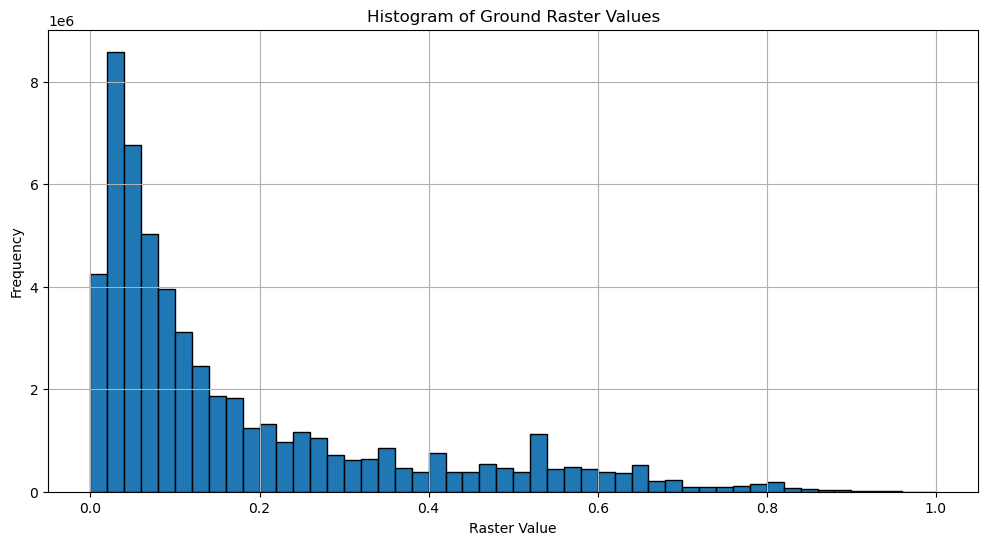

In [6]:


# File path
input_raster = './data/DSM/Circularity_brussels.tif'

# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
src.close
# Flatten the array to a 1D array and filter out nan values
raster_flat = raster_data.flatten()
raster_flat = raster_flat[~np.isnan(raster_flat)]

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.hist(raster_flat, bins=50, edgecolor='black', range=[0, 1])
plt.title('Histogram of Ground Raster Values')
plt.xlabel('Raster Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [11]:
#clip out the cars on Impermeable sufaces
# the cars are defined as the shapes with Circularity between 0.22 and 0.66
input_raster = './data/DSM/DSM-DTM_50cm_vegetation04-20.tif'
mask_raster = './data/DSM/Circularity_cars.tif'
output_raster = './data/DSM/DSM-DTM_50cm_vegetation04-20_without_cars.tif'

# Open the raster file
with rasterio.open(input_raster) as src:
    # Read the raster data
    raster_data = src.read(1)
    # Get the metadata
    meta = src.meta

# Open the raster file
with rasterio.open(mask_raster) as src:
    # Read the raster data
    mask_data = src.read(1)
    # Get the metadata
    #meta = src.meta
src.close
# Find values less than 0 and change them to 0

raster_data[mask_data > 0] = 0

raster_data = np.nan_to_num(raster_data, nan=0)

# Write the modified raster to a new file
with rasterio.open(output_raster, 'w', **meta) as dest:
    dest.write(raster_data, 1)
dest.close
print(f"Raster values modified and saved to '{output_raster}'")

Raster values modified and saved to './data/DSM/DSM-DTM_50cm_vegetation04-20_without_cars.tif'


## repeat these processes tille the profiles are all clean